In [1]:







import pandas as pd

In [2]:
import pandas as pd

customers = pd.read_csv("blinkit_customers_cleaned.csv")
orders = pd.read_csv("blinkit_orders_cleaned.csv")
products = pd.read_csv("blinkit_products_cleaned.csv")
order_items = pd.read_csv("blinkit_order_items_cleaned.csv")
feedback = pd.read_csv("blinkit_customer_feedback.csv")

In [3]:
customers.isnull().sum()
customers.duplicated().sum()
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        2500 non-null   int64  
 1   customer_name      2500 non-null   object 
 2   email              2500 non-null   object 
 3   phone              2500 non-null   float64
 4   address            2500 non-null   object 
 5   area               2500 non-null   object 
 6   pincode            2500 non-null   int64  
 7   registration_date  2500 non-null   object 
 8   customer_segment   2500 non-null   object 
 9   total_orders       2500 non-null   int64  
 10  avg_order_value    2500 non-null   float64
dtypes: float64(2), int64(3), object(6)
memory usage: 215.0+ KB


In [4]:
orders.isnull().sum()
orders.duplicated().sum()

np.int64(0)

In [5]:
products.isnull().sum()
products.duplicated().sum()

np.int64(0)

In [6]:
order_items.isnull().sum()
order_items.duplicated().sum()

np.int64(0)

In [7]:
feedback.isnull().sum()
feedback.duplicated().sum()

np.int64(0)

In [8]:
orders[~orders['customer_id'].isin(customers['customer_id'])]

,order_id,customer_id,order_date,promised_delivery_time,actual_delivery_time,delivery_status,order_total,payment_method,delivery_partner_id,store_id


In [9]:
order_items[~order_items['product_id'].isin(products['product_id'])]

,order_id,product_id,quantity,unit_price


In [10]:
feedback[~feedback['order_id'].isin(orders['order_id'])]

,feedback_id,order_id,customer_id,rating,feedback_text,feedback_category,sentiment,feedback_date


In [11]:
feedback[~feedback['customer_id'].isin(customers['customer_id'])]

,feedback_id,order_id,customer_id,rating,feedback_text,feedback_category,sentiment,feedback_date


In [12]:
feedback_orders = feedback.merge(orders, on='order_id')
feedback_products = feedback_orders.merge(order_items, on='order_id')
feedback_products = feedback_products.merge(products, on='product_id')

#average rating by category


In [13]:
feedback_products.groupby('category')['rating'].mean()

,rating
category,
Baby Care,3.296407
Cold Drinks & Juices,3.338667
Dairy & Breakfast,3.254417
Fruits & Vegetables,3.355691
Grocery & Staples,3.465479
Household Care,3.404715
Instant & Frozen Food,3.311798
Personal Care,3.288546
Pet Care,3.357285


#sentiment by product


In [14]:
feedback_products.groupby('product_name')['sentiment'].value_counts()

product_name  sentiment
Baby Food     Negative     41
              Neutral      39
              Positive     35
Baby Wipes    Negative     65
              Neutral      57
                           ..
Vitamins      Positive     57
              Negative     55
Wheat Flour   Positive     39
              Negative     37
              Neutral      34
Name: count, Length: 153, dtype: int64

In [15]:
feedback_products.head()
feedback_products.info()
feedback_products.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 29 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   feedback_id             5000 non-null   int64  
 1   order_id                5000 non-null   int64  
 2   customer_id_x           5000 non-null   int64  
 3   rating                  5000 non-null   int64  
 4   feedback_text           5000 non-null   object 
 5   feedback_category       5000 non-null   object 
 6   sentiment               5000 non-null   object 
 7   feedback_date           5000 non-null   object 
 8   customer_id_y           5000 non-null   int64  
 9   order_date              5000 non-null   object 
 10  promised_delivery_time  5000 non-null   object 
 11  actual_delivery_time    5000 non-null   object 
 12  delivery_status         5000 non-null   object 
 13  order_total             5000 non-null   float64
 14  payment_method          5000 non-null   

,feedback_id,order_id,customer_id_x,rating,customer_id_y,order_total,delivery_partner_id,store_id,product_id,quantity,unit_price,price,mrp,margin_percentage,shelf_life_days,min_stock_level,max_stock_level
count,5.000000e+03,5.000000e+03,5.000000e+03,5000.00000,5.000000e+03,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,5.013616e+06,5.029129e+09,5.009685e+07,3.34440,5.009685e+07,2201.86170,50050.318200,4999.689000,509974.939600,2.006800,493.157900,493.157900,685.912262,27.708000,235.241600,20.490400,75.124400
std,2.857341e+06,2.863533e+09,2.919082e+07,1.18982,2.919082e+07,1303.02438,28802.276922,2886.089242,293678.307475,0.820542,298.075647,298.075647,418.232417,7.430867,151.259042,5.984001,14.502999
min,9.470000e+02,6.046500e+04,3.181300e+04,1.00000,3.181300e+04,13.25000,43.000000,1.000000,4452.000000,1.000000,12.320000,12.320000,17.600000,15.000000,3.000000,10.000000,50.000000
25%,2.576690e+06,2.531421e+09,2.404314e+07,3.00000,2.404314e+07,1086.21500,24928.500000,2509.250000,257719.000000,1.000000,227.220000,227.220000,326.290000,20.000000,90.000000,15.000000,64.000000
50%,5.005833e+06,5.074378e+09,4.997808e+07,4.00000,4.997808e+07,2100.69000,50262.500000,4987.000000,540618.000000,2.000000,448.160000,448.160000,643.820000,30.000000,365.000000,21.000000,74.000000
75%,7.486478e+06,7.488579e+09,7.621215e+07,4.00000,7.621215e+07,3156.88250,74478.250000,7500.750000,747801.000000,3.000000,781.080000,781.080000,1061.660000,35.000000,365.000000,26.000000,88.000000
max,9.999293e+06,9.998298e+09,9.989390e+07,5.00000,9.989390e+07,6721.46000,99968.000000,9995.000000,993331.000000,3.000000,995.980000,995.980000,1633.320000,40.000000,365.000000,30.000000,100.000000


In [16]:
feedback_products.isnull().sum()

,0
feedback_id,0
order_id,0
customer_id_x,0
rating,0
feedback_text,0
feedback_category,0
sentiment,0
feedback_date,0
customer_id_y,0
order_date,0


In [17]:
#Rating distribution
feedback_products['rating'].value_counts()

,count
rating,
4,1708
3,1398
5,816
1,540
2,538


In [18]:
#category wise average rating
feedback_products.groupby('category')['rating'].mean().sort_values()

,rating
category,
Dairy & Breakfast,3.254417
Personal Care,3.288546
Baby Care,3.296407
Instant & Frozen Food,3.311798
Snacks & Munchies,3.329193
Cold Drinks & Juices,3.338667
Fruits & Vegetables,3.355691
Pet Care,3.357285
Pharmacy,3.378378


In [19]:
#top selling products
feedback_products.groupby('product_name')['quantity'].sum().sort_values(ascending=False).head(10)

,quantity
product_name,
Pet Treats,473
Toilet Cleaner,430
Dish Soap,397
Vitamins,380
Cough Syrup,373
Lotion,350
Baby Wipes,328
Cat Food,307
Pulses,273


In [20]:
#revenue by category
feedback_products['revenue'] = feedback_products['quantity'] * feedback_products['unit_price']

In [21]:
feedback_products.groupby('category')['revenue'].sum().sort_values(ascending=False)

,revenue
category,
Dairy & Breakfast,639222.19
Pharmacy,592368.57
Fruits & Vegetables,559053.08
Pet Care,539888.75
Household Care,444244.25
Personal Care,394894.61
Snacks & Munchies,394648.71
Cold Drinks & Juices,392717.62
Grocery & Staples,359937.82


In [22]:
#delivery performance
orders['delivery_status'].value_counts()

,count
delivery_status,
On Time,3470
Slightly Delayed,1037
Significantly Delayed,493


In [23]:
#sentiment analysis
feedback_products['sentiment'].value_counts()

,count
sentiment,
Neutral,1738
Negative,1642
Positive,1620


In [24]:
import matplotlib.pyplot as plt

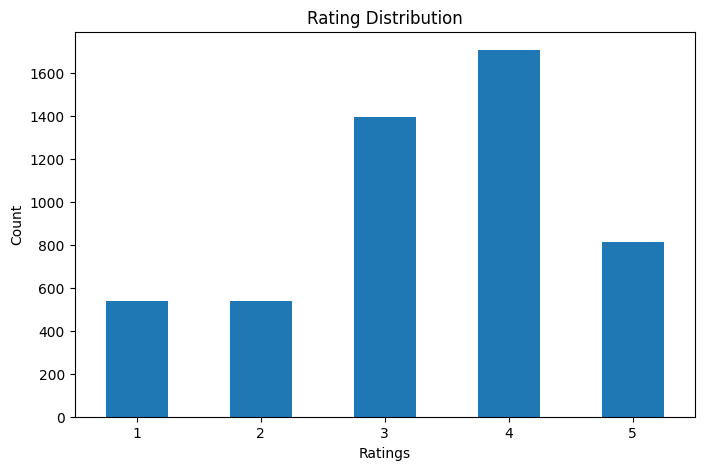

In [25]:
#rating distribution
feedback_products['rating'].value_counts().sort_index().plot(
    kind='bar',
    figsize=(8,5)
)
plt.xticks(rotation=60)
plt.title('Rating Distribution')
plt.xlabel('Ratings')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

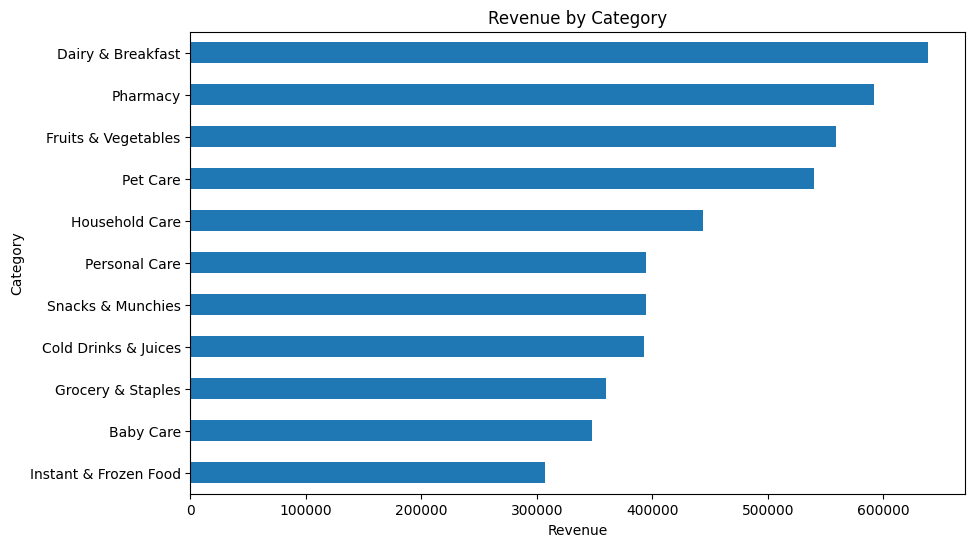

In [26]:
#category wise revenue
category_sales = feedback_products.groupby('category')['revenue'].sum().sort_values()

category_sales.plot(
    kind='barh',
    figsize=(10,6)
)

plt.title('Revenue by Category')
plt.xlabel('Revenue')
plt.ylabel('Category')
plt.show()

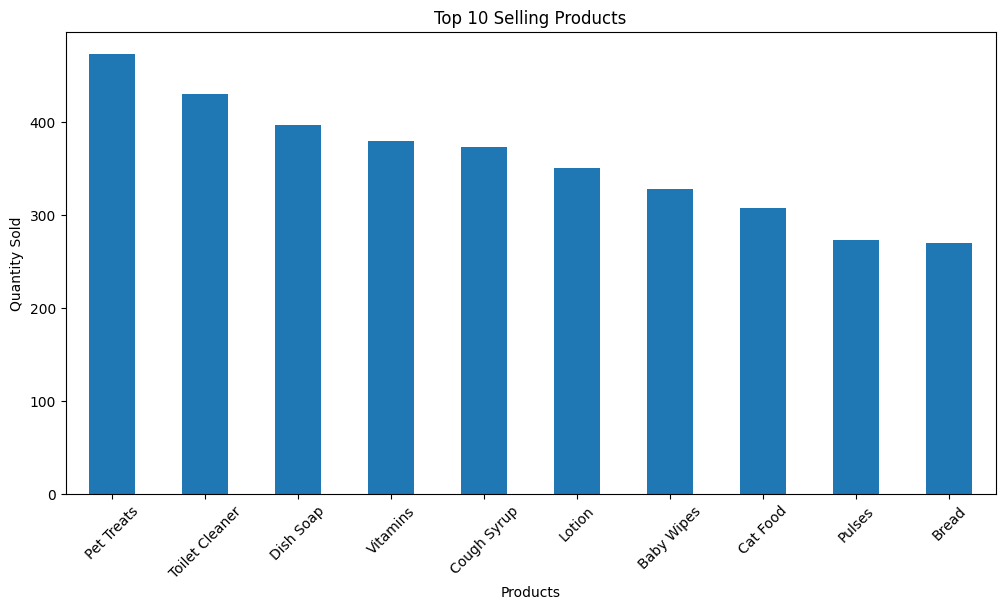

In [27]:
#Top 10 selling products
top_products = feedback_products.groupby('product_name')['quantity'].sum().sort_values(ascending=False).head(10)

top_products.plot(
    kind='bar',
    figsize=(12,6)
)

plt.title('Top 10 Selling Products')
plt.xlabel('Products')
plt.ylabel('Quantity Sold')
plt.xticks(rotation=45)
plt.show()

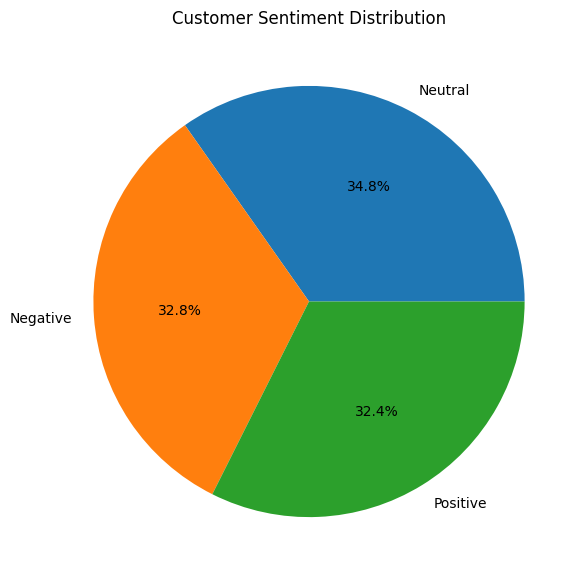

In [28]:
#Sentiment distribution pie chart
feedback_products['sentiment'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(7,7)
)

plt.title('Customer Sentiment Distribution')
plt.ylabel('')
plt.show()

/tmp/ipykernel_744/3708226594.py:2: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  feedback_products['order_date'] = pd.to_datetime(feedback_products['order_date'])


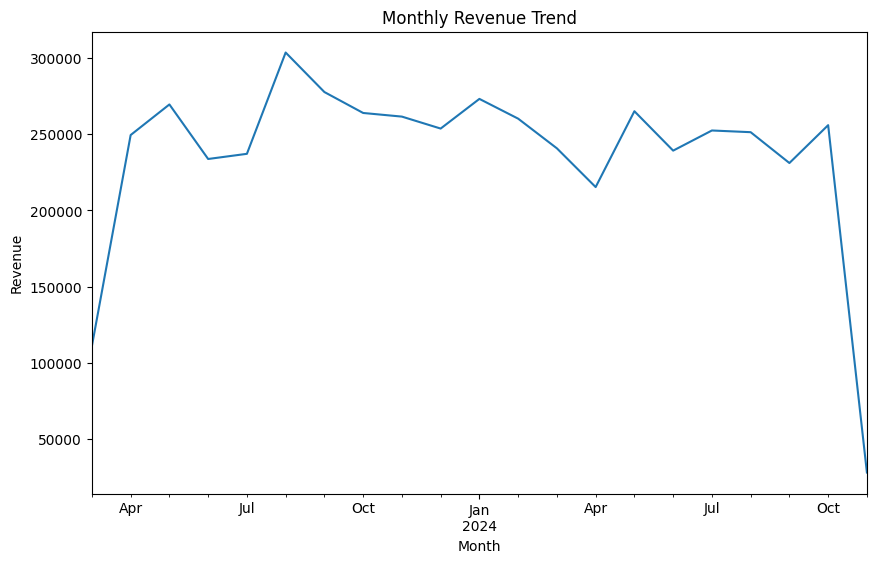

In [29]:
#Monthly revenue trend
feedback_products['order_date'] = pd.to_datetime(feedback_products['order_date'])

monthly_sales = feedback_products.groupby(
    feedback_products['order_date'].dt.to_period('M')
)['revenue'].sum()

monthly_sales.plot(
    kind='line',
    figsize=(10,6)
)

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.show()

### Monthly Revenue Trend Interpretation:
- Revenue remains relatively stable between 230K–280K for most months, showing consistent customer demand.
- There is a noticeable revenue peak around August 2023 (~300K), indicating a high-sales period.
- A decline is visible around April 2024, suggesting lower customer purchases or seasonal impact.
- Revenue recovers again in the following months, showing business resilience.
- The sharp drop at the last point is likely incomplete data for the current month, not an actual performance decline.

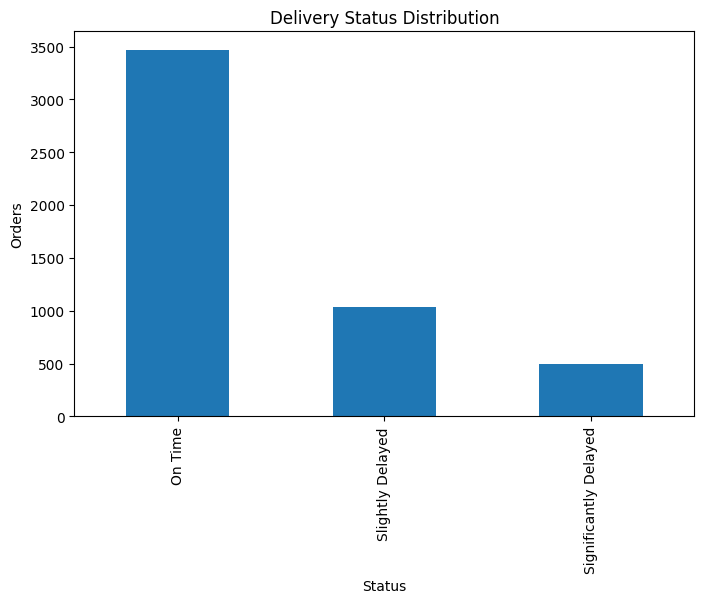

In [30]:
#Delivery status count
orders['delivery_status'].value_counts().plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Delivery Status Distribution')
plt.xlabel('Status')
plt.ylabel('Orders')
plt.show()

In [31]:
numeric_cols = feedback_products[['quantity', 'unit_price', 'rating', 'revenue']]

corr = numeric_cols.corr()
print(corr)

            quantity  unit_price    rating   revenue
quantity    1.000000    0.019686  0.001289  0.540091
unit_price  0.019686    1.000000 -0.006432  0.790421
rating      0.001289   -0.006432  1.000000 -0.004560
revenue     0.540091    0.790421 -0.004560  1.000000


### Interpretation:
- Revenue has a strong positive correlation (0.79) with unit price, showing that higher-priced products contribute more to revenue.
- Quantity has a moderate positive correlation (0.54) with revenue, indicating sales volume also impacts revenue.
- Ratings have almost no correlation with revenue, price, or quantity, suggesting customer satisfaction is independent of sales performance.

In [32]:
customer_spending = feedback_products.groupby('customer_id_x')['revenue'].sum()

customer_spending.describe()

,revenue
count,2172.000000
mean,2289.325704
std,1713.517602
min,12.320000
25%,919.787500
50%,1959.980000
75%,3225.060000
max,10533.390000


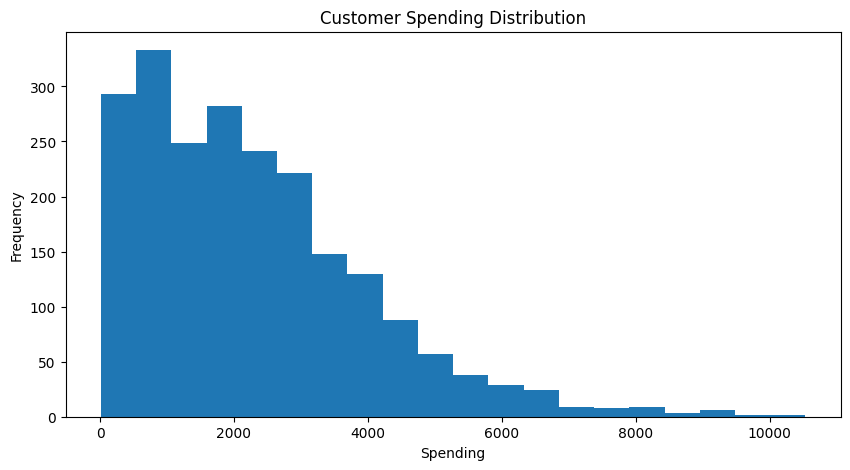

In [33]:
customer_spending.plot(kind='hist', figsize=(10,5), bins=20)

plt.title('Customer Spending Distribution')
plt.xlabel('Spending')
plt.show()

### Interpretation:
- Customer spending is positively skewed, with the majority of customers spending between low and moderate amounts.
- A small group of customers contributes significantly higher spending, creating the long right tail.
- This indicates the presence of high-value customers who contribute disproportionately to revenue.
- The business can target these high spenders with loyalty programs and personalized offers.

In [34]:
delay_analysis = orders['delivery_status'].value_counts(normalize=True) * 100
print(delay_analysis)

delivery_status
On Time                  69.40
Slightly Delayed         20.74
Significantly Delayed     9.86
Name: proportion, dtype: float64


### Interpretation:
- 69.40% of orders were delivered on time, indicating that the majority of deliveries are meeting expected timelines.
- 20.74% of orders experienced slight delays, showing moderate inefficiencies in delivery operations.
- 9.86% of orders were significantly delayed, which represents a smaller but critical area for improvement.
- Overall, while delivery performance is strong, nearly 30% of orders faced delays, which could affect customer satisfaction and retention.

In [35]:
#Category-wise Satisfaction
feedback_products.groupby('category')['rating'].mean().sort_values()

,rating
category,
Dairy & Breakfast,3.254417
Personal Care,3.288546
Baby Care,3.296407
Instant & Frozen Food,3.311798
Snacks & Munchies,3.329193
Cold Drinks & Juices,3.338667
Fruits & Vegetables,3.355691
Pet Care,3.357285
Pharmacy,3.378378


In [36]:
#Creating Features for Prediction
orders['delay_flag'] = orders['delivery_status'].apply(
    lambda x: 0 if x == 'On Time' else 1
)

In [37]:
orders.columns

Index(['order_id', 'customer_id', 'order_date', 'promised_delivery_time',
       'actual_delivery_time', 'delivery_status', 'order_total',
       'payment_method', 'delivery_partner_id', 'store_id', 'delay_flag'],
      dtype='object')

In [38]:
orders['actual_delivery_time'] = pd.to_datetime(orders['actual_delivery_time'])
orders['order_date'] = pd.to_datetime(orders['order_date'])

/tmp/ipykernel_744/1987417157.py:1: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  orders['actual_delivery_time'] = pd.to_datetime(orders['actual_delivery_time'])
/tmp/ipykernel_744/1987417157.py:2: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  orders['order_date'] = pd.to_datetime(orders['order_date'])


In [39]:
orders['delivery_minutes'] = (
    orders['actual_delivery_time'] - orders['order_date']
).dt.total_seconds() / 60

In [40]:
X = orders[['order_total', 'delivery_minutes']]
y = orders['delay_flag']

In [41]:
#Train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [42]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [43]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[0 1 0 0 0 0 0 1 0 0]


In [44]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.909


In [45]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[667  34]
 [ 57 242]]


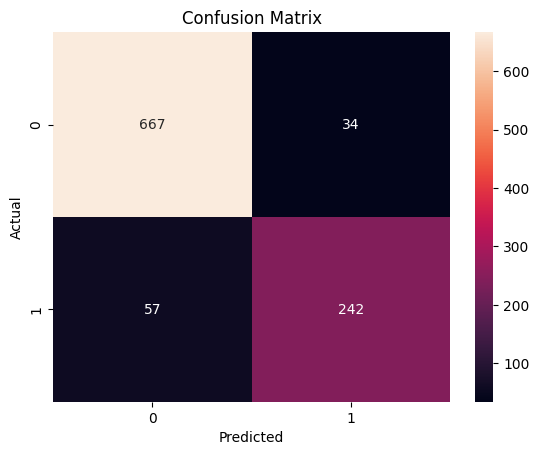

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

### Confusion Matrix Interpretation:
The model correctly classified 667 on-time deliveries and 242 delayed deliveries. It made only 34 false delay predictions and missed 57 actual delayed orders. With an overall accuracy of 90.9%, the model performs well in predicting delivery status and can help improve logistics planning.

In [47]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.95      0.94       701
           1       0.88      0.81      0.84       299

    accuracy                           0.91      1000
   macro avg       0.90      0.88      0.89      1000
weighted avg       0.91      0.91      0.91      1000



In [48]:
customer_features = feedback_products.groupby('customer_id_x').agg({
    'revenue':'sum',
    'quantity':'sum',
    'rating':'mean'
}).reset_index()

In [49]:
from sklearn.preprocessing import StandardScaler

X = customer_features[['revenue','quantity','rating']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

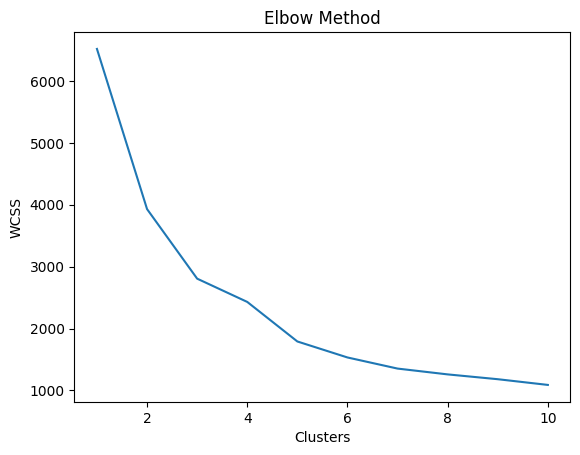

In [50]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss)
plt.xlabel('Clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

### Interpretation:
- The WCSS (Within Cluster Sum of Squares) decreases sharply from 1 to 3 clusters.
- After 3 clusters, the reduction becomes slower and more gradual.
- This point where the curve starts flattening is called the "elbow point."
- Therefore, 3 clusters is the optimal choice because it balances segmentation quality and model simplicity.

In [51]:
kmeans = KMeans(n_clusters=3, random_state=42)

customer_features['Cluster'] = kmeans.fit_predict(X_scaled)

In [52]:
customer_features.groupby('Cluster').mean()

,customer_id_x,revenue,quantity,rating
Cluster,,,,
0,4.947428e+07,1410.102466,3.208475,3.763983
1,5.020781e+07,1672.939237,3.523684,1.943202
2,5.130477e+07,4367.283676,8.021242,3.388461


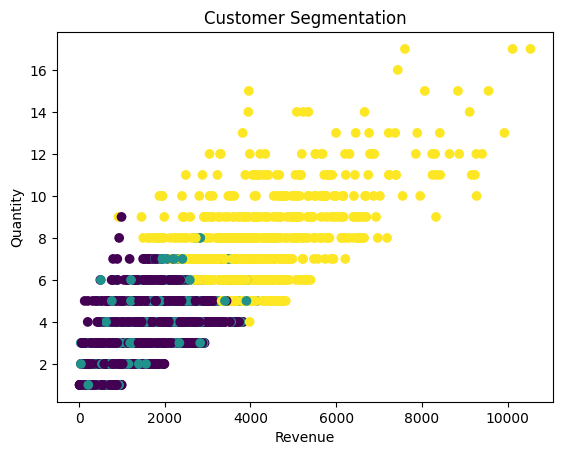

In [53]:
plt.scatter(
    customer_features['revenue'],
    customer_features['quantity'],
    c=customer_features['Cluster']
)

plt.xlabel('Revenue')
plt.ylabel('Quantity')
plt.title('Customer Segmentation')
plt.show()

### Interpretation:
- The scatter plot shows a clear positive relationship between revenue and quantity purchased, meaning customers who buy more products generally spend more.
- K-means clustering has divided customers into three segments based on purchasing behavior.
- The lower-left cluster represents low-value customers with low spending and fewer purchases.
- The middle cluster represents medium-value customers with moderate spending and purchase frequency.
- The upper-right cluster represents high-value customers who purchase more and generate the highest revenue.


### Business Insight:
A small segment of high-value customers contributes significantly more revenue compared to the majority of low-value customers.

### Recommendation:
- Target high-value customers with loyalty rewards and premium offers.
- Upsell medium-value customers to increase spending.
- Re-engage low-value customers with discounts and personalized recommendations.